# CartPole PPO

## 实验目标

本实验使用 `PPO` 训练 CartPole 的离散动作策略。目标是让智能体学会在连续状态空间下稳定控制倒立摆，使小车在有限范围内持续修正位置和角速度，从而尽可能长时间保持杆接近竖直。这里的重点不仅是把训练跑起来，还要把 `PPO` 作为现代策略优化方法在小型控制任务上的训练结构讲清楚。


## 为什么这里选择 PPO

虽然 CartPole 是经典的 `DQN` 环境，但它同样适合拿来展示 `PPO`，原因包括：

- 动作空间虽然离散，但 `PPO` 对离散动作同样适用
- 训练结构更统一，后续更容易迁移到更复杂任务
- 能自然使用多进程向量环境提高采样吞吐
- 更容易体现现代策略优化方法的工程路线

因此，这里加入 `PPO`，不是为了替代 `DQN` / `Double DQN`，而是提供一条更现代、更统一的对照路径。


## 收敛判断方式

这个 notebook 不会笼统地说“已经学会”，而是通过几组具体信号判断训练是否进入稳定阶段：

- episode return 是否持续改善
- 最近回合的平均长度是否逐步接近回合上限
- 最近稳定率是否明显高于随机基线
- 固定评估阶段的平均回报和稳定率是否达到稳定水平
- 策略切片图上是否出现连贯的动作概率边界

只有这些信号同时成立，才说明 `PPO` 不是偶尔撑住几局，而是真的学到了有意义的平衡控制规律。


## 设备与多进程说明

- 环境采样使用 `SubprocVecEnv` 多进程向量环境
- 环境步进由多个 CPU 进程并行完成
- 策略网络优先自动选择 `CUDA`
- 如果没有 `CUDA`，则尝试 `MPS`
- 都不可用时回退到 `CPU`

这里的重点是把 `PPO` 的多环境采样结构做完整，而不是只在单环境里串行收集轨迹。


In [1]:
import os
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import SubprocVecEnv
from tqdm.auto import tqdm


In [2]:
ENV_ID = "CartPole-v1"
AVAILABLE_CPUS = os.cpu_count() or 1
NUM_ENVS = min(AVAILABLE_CPUS, 24)
TOTAL_TIMESTEPS = 100000
N_STEPS = 32
BATCH_SIZE = 256
N_EPOCHS = 10
LEARNING_RATE = 1e-3
GAMMA = 0.98
GAE_LAMBDA = 0.8
ENT_COEF = 0.0
VF_COEF = 0.5
MAX_GRAD_NORM = 0.5
EVAL_EPISODES = 100
ROLLOUT_EPISODES = 3
ROLLOUT_FPS = 30
MAX_STEPS = 500
SUCCESS_THRESHOLD = 475
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

DEVICE, NUM_ENVS


('mps', 24)

## 参数选择说明

这里的参数选择是偏稳的一版默认设置，重点是让 CartPole 在多进程 `PPO` 结构下稳定收敛：

- `NUM_ENVS`：根据本机 CPU 数量自动设置，并优先放开到 `24` 个进程，尽量提高轨迹采样吞吐
- `TOTAL_TIMESTEPS = 100000`：在总时间更紧凑的前提下，保留足够训练预算让策略边界成形
- `N_STEPS = 32`：缩短单轮 rollout，提高 24 进程下的策略更新频率
- `BATCH_SIZE = 256`：与更短 rollout 配合，保持更新粒度更细
- `N_EPOCHS = 10`：提高每轮 rollout 的利用率，让策略在较短预算内更充分更新
- `LEARNING_RATE = 1e-3`：采用更积极的一版起点，加快 CartPole 这类小任务的收敛速度
- `GAE_LAMBDA = 0.8`：收紧优势估计的时间范围，减小小任务里的方差
- `SUCCESS_THRESHOLD = 475`：把接近回合上限的表现视为稳定控制的近似标准

如果训练后回报仍明显波动，优先调整的方向通常是：

- 提高 `TOTAL_TIMESTEPS`
- 调整 `N_STEPS` 和 `BATCH_SIZE`
- 继续微调学习率


In [3]:
def make_env(rank):
    def _init():
        env = Monitor(gym.make(ENV_ID))
        env.reset(seed=SEED + rank)
        return env
    return _init


class EpisodeStatsCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_returns = []
        self.episode_lengths = []
        self.episode_successes = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        for info in infos:
            if "episode" in info:
                episode_return = float(info["episode"]["r"])
                episode_length = int(info["episode"]["l"])
                self.episode_returns.append(episode_return)
                self.episode_lengths.append(episode_length)
                self.episode_successes.append(int(episode_length >= SUCCESS_THRESHOLD))
        return True


In [4]:
train_env = SubprocVecEnv([make_env(i) for i in range(NUM_ENVS)], start_method="fork")
callback = EpisodeStatsCallback()

model = PPO(
    policy="MlpPolicy",
    env=train_env,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,
    learning_rate=LEARNING_RATE,
    gamma=GAMMA,
    gae_lambda=GAE_LAMBDA,
    ent_coef=ENT_COEF,
    vf_coef=VF_COEF,
    max_grad_norm=MAX_GRAD_NORM,
    policy_kwargs=dict(net_arch=[128, 128]),
    verbose=0,
    device=DEVICE,
    seed=SEED,
)

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback, progress_bar=True)
train_env.close()


Output()

/opt/anaconda3/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [5]:
episode_return_series = pd.Series(callback.episode_returns, dtype=float)
episode_length_series = pd.Series(callback.episode_lengths, dtype=float)
episode_success_series = pd.Series(callback.episode_successes, dtype=float)

rolling_return = episode_return_series.rolling(50).mean() if len(episode_return_series) >= 50 else episode_return_series
rolling_length = episode_length_series.rolling(50).mean() if len(episode_length_series) >= 50 else episode_length_series
rolling_success = episode_success_series.rolling(50).mean() if len(episode_success_series) >= 50 else episode_success_series


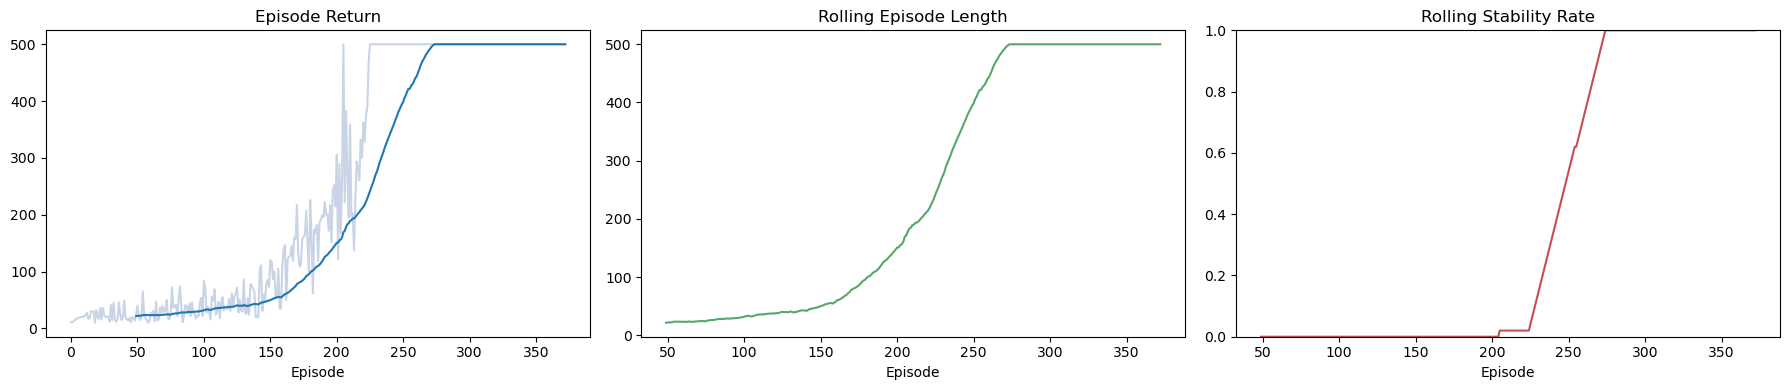

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(callback.episode_returns, alpha=0.30, color="#4c72b0")
axes[0].plot(rolling_return, color="#1f77b4")
axes[0].set_title("Episode Return")
axes[0].set_xlabel("Episode")

axes[1].plot(rolling_length, color="#55a868")
axes[1].set_title("Rolling Episode Length")
axes[1].set_xlabel("Episode")

axes[2].plot(rolling_success, color="#c44e52")
axes[2].set_title("Rolling Stability Rate")
axes[2].set_xlabel("Episode")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ppo_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
def policy_outputs_for_state(state):
    obs_tensor = torch.tensor(state, dtype=torch.float32, device=model.device).unsqueeze(0)
    with torch.no_grad():
        distribution = model.policy.get_distribution(obs_tensor).distribution
        probs = distribution.probs.squeeze(0).cpu().numpy()
        value = float(model.policy.predict_values(obs_tensor).item())
    return probs, value


def build_policy_slice(cart_position=0.0, cart_velocity=0.0):
    pole_angles = np.linspace(-0.209, 0.209, 41)
    pole_angular_velocities = np.linspace(-2.5, 2.5, 41)
    action1_prob_map = np.zeros((len(pole_angles), len(pole_angular_velocities)), dtype=float)
    value_map = np.zeros((len(pole_angles), len(pole_angular_velocities)), dtype=float)

    for i, pole_angle in enumerate(pole_angles):
        for j, pole_ang_vel in enumerate(pole_angular_velocities):
            state = np.array([cart_position, cart_velocity, pole_angle, pole_ang_vel], dtype=np.float32)
            probs, value = policy_outputs_for_state(state)
            action1_prob_map[i, j] = float(probs[1])
            value_map[i, j] = value

    return pole_angles, pole_angular_velocities, action1_prob_map, value_map


pole_angles, pole_ang_vels, action1_prob_map, value_map = build_policy_slice()


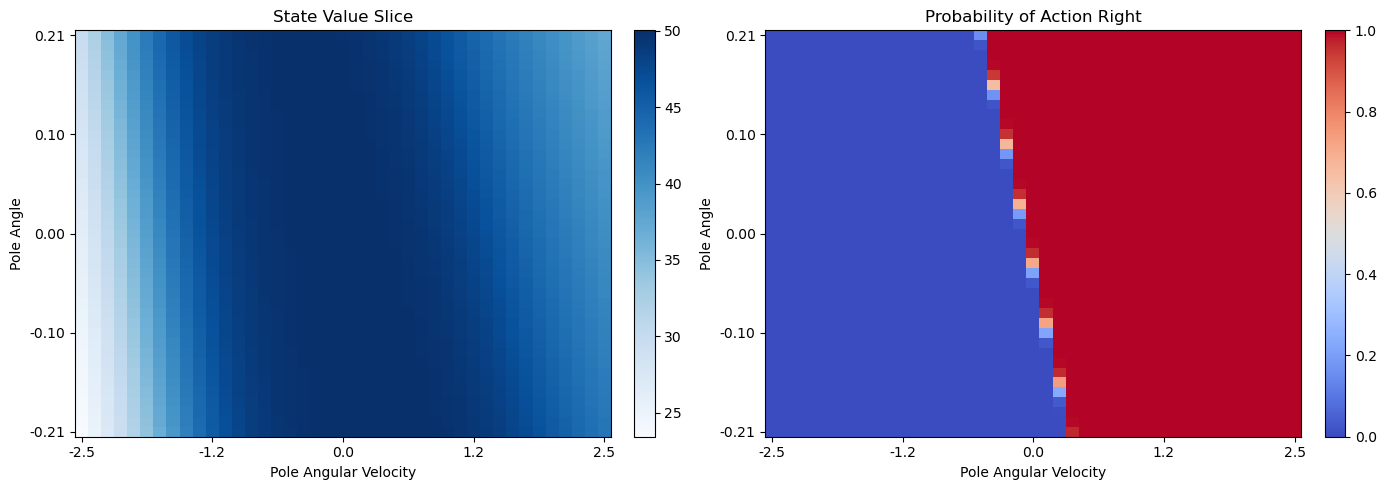

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(value_map, origin="lower", aspect="auto", cmap="Blues")
axes[0].set_title("State Value Slice")
axes[0].set_xlabel("Pole Angular Velocity")
axes[0].set_ylabel("Pole Angle")
axes[0].set_xticks(np.linspace(0, len(pole_ang_vels) - 1, 5, dtype=int))
axes[0].set_xticklabels([f"{pole_ang_vels[idx]:.1f}" for idx in np.linspace(0, len(pole_ang_vels) - 1, 5, dtype=int)])
axes[0].set_yticks(np.linspace(0, len(pole_angles) - 1, 5, dtype=int))
axes[0].set_yticklabels([f"{pole_angles[idx]:.2f}" for idx in np.linspace(0, len(pole_angles) - 1, 5, dtype=int)])
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(action1_prob_map, origin="lower", aspect="auto", cmap="coolwarm", vmin=0, vmax=1)
axes[1].set_title("Probability of Action Right")
axes[1].set_xlabel("Pole Angular Velocity")
axes[1].set_ylabel("Pole Angle")
axes[1].set_xticks(np.linspace(0, len(pole_ang_vels) - 1, 5, dtype=int))
axes[1].set_xticklabels([f"{pole_ang_vels[idx]:.1f}" for idx in np.linspace(0, len(pole_ang_vels) - 1, 5, dtype=int)])
axes[1].set_yticks(np.linspace(0, len(pole_angles) - 1, 5, dtype=int))
axes[1].set_yticklabels([f"{pole_angles[idx]:.2f}" for idx in np.linspace(0, len(pole_angles) - 1, 5, dtype=int)])
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ppo_policy_visualization.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
eval_env = gym.make(ENV_ID)
eval_returns = []
eval_lengths = []
eval_successes = []

for episode in tqdm(range(EVAL_EPISODES), desc="Policy evaluation"):
    obs, info = eval_env.reset(seed=SEED + 20000 + episode)
    total_reward = 0.0

    for step in range(MAX_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(int(action))
        total_reward += reward
        if terminated or truncated:
            episode_length = step + 1
            break
    else:
        episode_length = MAX_STEPS

    eval_returns.append(total_reward)
    eval_lengths.append(episode_length)
    eval_successes.append(int(episode_length >= SUCCESS_THRESHOLD))

eval_env.close()


Policy evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

In [10]:
eval_avg_return = float(np.mean(eval_returns))
eval_return_std = float(np.std(eval_returns))
eval_avg_length = float(np.mean(eval_lengths))
eval_success_rate = float(np.mean(eval_successes))

metrics = pd.DataFrame(
    {
        "metric": [
            "device",
            "num_envs",
            "total_timesteps",
            "recent_episode_return_last_50",
            "recent_episode_length_last_50",
            "recent_stability_rate_last_50",
            "evaluation_average_return",
            "evaluation_return_std",
            "evaluation_average_length",
            "evaluation_stability_rate",
        ],
        "value": [
            DEVICE,
            NUM_ENVS,
            TOTAL_TIMESTEPS,
            float(episode_return_series.tail(50).mean()) if len(episode_return_series) > 0 else 0.0,
            float(episode_length_series.tail(50).mean()) if len(episode_length_series) > 0 else 0.0,
            float(episode_success_series.tail(50).mean()) if len(episode_success_series) > 0 else 0.0,
            eval_avg_return,
            eval_return_std,
            eval_avg_length,
            eval_success_rate,
        ],
    }
)
metrics


,metric,value
0,device,mps
1,num_envs,24
2,total_timesteps,100000
3,recent_episode_return_last_50,500.0
4,recent_episode_length_last_50,500.0
5,recent_stability_rate_last_50,1.0
6,evaluation_average_return,500.0
7,evaluation_return_std,0.0
8,evaluation_average_length,500.0
9,evaluation_stability_rate,1.0


In [11]:
rollout_summaries = []
for rollout_idx in range(ROLLOUT_EPISODES):
    rollout_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = rollout_env.reset(seed=SEED + 30000 + rollout_idx)
    frames = []
    total_reward = 0.0

    for step in range(MAX_STEPS):
        frame = rollout_env.render()
        if frame is not None:
            frames.append(frame)

        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = rollout_env.step(int(action))
        total_reward += reward

        if terminated or truncated:
            final_frame = rollout_env.render()
            if final_frame is not None:
                frames.append(final_frame)
            rollout_summaries.append(
                {
                    "rollout_index": rollout_idx + 1,
                    "seed": SEED + 30000 + rollout_idx,
                    "total_reward": total_reward,
                    "steps": step + 1,
                }
            )
            break

    rollout_env.close()
    if frames:
        imageio.mimsave(RESULTS_DIR / f"ppo_rollout_{rollout_idx + 1}.gif", frames, fps=ROLLOUT_FPS)


In [12]:
metrics.to_csv(RESULTS_DIR / "ppo_metrics.csv", index=False)
pd.DataFrame({"episode_return": callback.episode_returns}).to_csv(RESULTS_DIR / "ppo_episode_returns.csv", index=False)
pd.DataFrame({"episode_length": callback.episode_lengths}).to_csv(RESULTS_DIR / "ppo_episode_lengths.csv", index=False)
pd.DataFrame({"episode_success": callback.episode_successes}).to_csv(RESULTS_DIR / "ppo_episode_successes.csv", index=False)
pd.DataFrame({"evaluation_return": eval_returns, "evaluation_length": eval_lengths, "evaluation_success": eval_successes}).to_csv(RESULTS_DIR / "ppo_eval_results.csv", index=False)
pd.DataFrame(rollout_summaries).to_csv(RESULTS_DIR / "ppo_rollout_summary.csv", index=False)

print(f"Recent average return (last 50): {episode_return_series.tail(50).mean():.2f}")
print(f"Recent average length (last 50): {episode_length_series.tail(50).mean():.2f}")
print(f"Recent stability rate (last 50): {episode_success_series.tail(50).mean():.4f}")
print(f"Evaluation average return: {eval_avg_return:.2f}")
print(f"Evaluation average length: {eval_avg_length:.2f}")
print(f"Evaluation stability rate: {eval_success_rate:.4f}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")


Recent average return (last 50): 500.00
Recent average length (last 50): 500.00
Recent stability rate (last 50): 1.0000
Evaluation average return: 500.00
Evaluation average length: 500.00
Evaluation stability rate: 1.0000
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/08-cartpole-double-dqn/results


## 结果解读

训练完成后，重点观察以下内容：

- episode return 和 episode length 是否持续改善
- 稳定率是否从接近随机水平明显提升
- 策略概率切片图上是否出现连贯的动作边界
- 固定评估阶段是否能稳定接近回合上限

如果这些现象都成立，就说明 `PPO` 已经在连续状态空间中学到了有效的平衡控制策略。这个实验最重要的意义在于，它展示了多进程采样下的现代策略优化路线。
